In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

df = pd.read_csv("iris.csv")

print(df.head())

if 'species' in df.columns:
    X = df.drop('species', axis=1)
else:
    X = df.copy()

X = X.values  # convert to numpy array

   150    4  setosa  versicolor  virginica
0  5.1  3.5     1.4         0.2          0
1  4.9  3.0     1.4         0.2          0
2  4.7  3.2     1.3         0.2          0
3  4.6  3.1     1.5         0.2          0
4  5.0  3.6     1.4         0.2          0


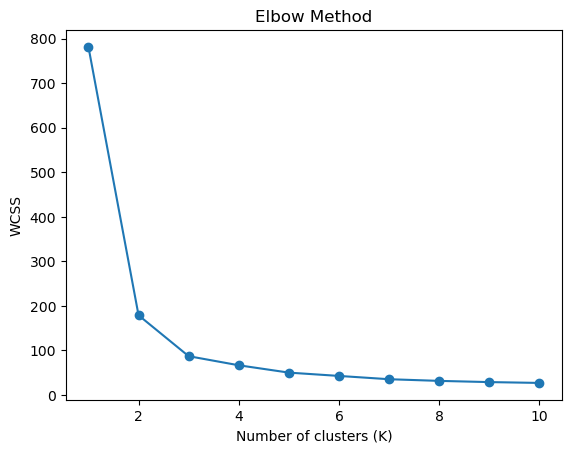

In [2]:
wcss = []

for k in range(1, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X)
    wcss.append(model.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of clusters (K)")
plt.ylabel("WCSS")
plt.show()

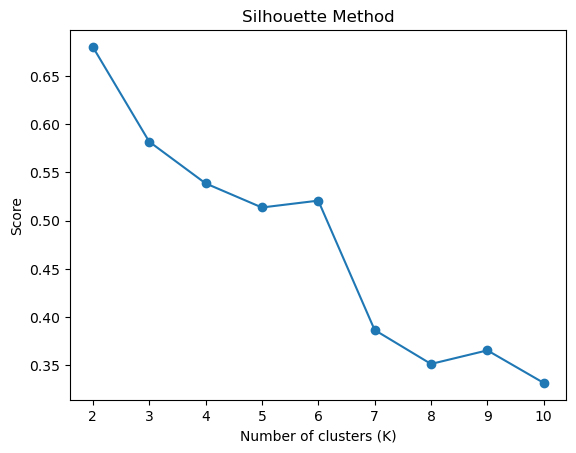

Optimal number of clusters: 2


In [3]:
sil_scores = []

for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X)
    sil_scores.append(silhouette_score(X, labels))

plt.plot(range(2, 11), sil_scores, marker='o')
plt.title("Silhouette Method")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Score")
plt.show()

# Best K
best_k = np.argmax(sil_scores) + 2
print("Optimal number of clusters:", best_k)

In [4]:
final_model = KMeans(n_clusters=best_k, random_state=42, n_init=10)
clusters = final_model.fit_predict(X)

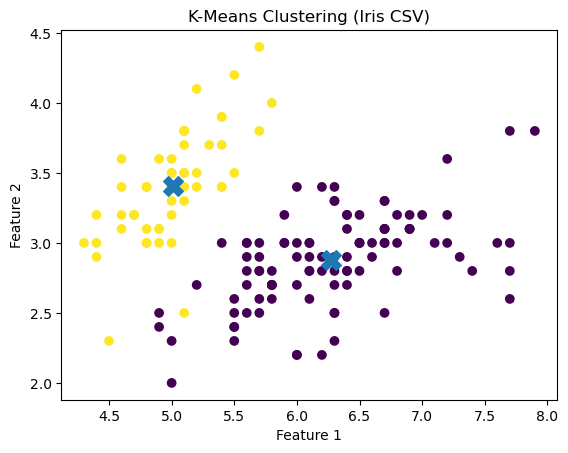

In [ ]:
plt.scatter(X[:, 0], X[:, 1], c=clusters)
plt.scatter(final_model.cluster_centers_[:, 0],
            final_model.cluster_centers_[:, 1],
            marker='X', s=200)

plt.title("K-Means Clustering (Iris DATA)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()